# White Balance
Informatia captata de un aparat de fotografiat trece printr-o serie de transformari pentru a fi transformata in versiunea finala a imaginii. Una dintre aceste transformari este legata de afisarea culorilor atunci cand scena curenta este expusa la o sursa de luminina colorata (adica nu este alba). Procesul de corectie a problemelor aparute in acest caz se numeste "white balance" si este incadrat in zona de specializare a "constantei culorilor".

Culoarea unei suprafete este obtinuta prin lumina ramasa (reflectata) in urma absorbtiei unei a parti a spectrului razelor de lumina incidente emise de o sursa de lumina. Informatia reflectata este filtrata de catre ochiul uman si apoi procesata de catre cortexul vizual. Fiind un sistem mult mai complex, sistemul vizual uman poate sa identifice, intr-o oarecare masura, culoarea sursei de lumina, suprafetei si culoarea perceputa a suprafetei. In contrast cu acesta, o camera poate sa indetifice doar culoarea perceputa a suprafetei. Scopul algoritmilor de <i>white balance</i> este deci sa identifice culoarea reala a obiectelor din imagine (adica culoarea daca ar fi fost folosita lumina alba).
<img src="wb_1.png"><center> Un observator uman poate identifica care sunt zonele albe din aceasta imagine, chiar daca arata albastre in acest caz</center>
Sa presupunem ca functia care caracterizeaza din punct de vedere spectral (al lungimilor de unda) sursa de lumina este $S(\lambda)$. Un obiect este caracterizat de functia de transfer $H(\lambda)$, avand forma:
$$ H(\lambda)=
\begin{cases}
1 & \lambda \ \epsilon \ D_H\\
0 & in \ rest\end{cases}$$

Alegerea valorii de 1 este mai aproape de un caz teoretic, dar care usureaza explicatia, in practica fiind mai probabile valori neunitare si variabile. Domeniul $D_H$ este domeniul in care reflexia este perfecta, adica domeniul in care se formeaza culoarea. De exemplu, daca $D_H=[600nm;700nm]$ obiectul va fi rosu; daca $D_H=[400nm;500nm]\cap[600nm;700nm]$ obiectul va fi albastru + rosu = violet.

Culoarea inregistrabila a obiectului caracterizat de $H(\lambda)$ iluminat de sursa de lumina caracterizata de $S(\lambda)$ este data de catre functia spectrala $X(\lambda)$:
$$X(\lambda)=S(\lambda)\times H(\lambda)$$
Daca functia spectrala a sursei de lumina corespunde intregului domeniu vizibil (aproximativ $[400nm,700nm]$), atunci $X(\lambda)$ va corespunde in domeniul de interes cu $H(\lambda)$ si culoarea inregistrabila va fi culoarea corecta. In acest caz (cel optim) se spune ca sursa de lumina are culoarea alba (contine toate componentele cromatice care, compuse, formeaza lumina alba, sau incolora). Dar acest lucru nu este intotdeauna intalnit in practica. Atunci daca:
$$ H(\lambda)=
\begin{cases}
1 & \lambda \ \epsilon \ D_S\\
0 & in \ rest\end{cases}$$
inseamna ca functia spectrala rezultanta a obiectului este:
$$ H(\lambda)=
\begin{cases}
1 & \lambda \ \epsilon \ D_S\cap D_H\\
0 & in \ rest\end{cases}$$
Ecuatia de mai sus ne arata ca crominanta inregistrabila a obiectului este data de fapt de intersectia domeniilor $D_S$ si $D_H$. In acest caz, culoarea obiectului nu mai este cea perceputa de ochiul uman.

O alta latura a problemei este data de faptul ca un observator uman, odata ce a observat un obiect si a memorat culoarea lui, se asteapta ca in orice imagine acel obiect sa aiba culoarea cunosuta. De exemplu, o coala de hartie va fi perceputa ca fiind alba chiar daca este iluminata de catre un bec incandescent (deci culoare rosiatica). Culorile obiectelor sunt memorate ca fiind iluminate de catre culoarea soarelui, care este alba (incolora). Acest fenomen este cunoscut sub denumirea de <i>constanta culorilor</i> si poate fi observat in prima figura, de mai sus. De asemenea, in figura de mai jos se poate vedea aceeasi scena cu diversi iluminanti ((a) alb, (b) rosu, (c) albastru).
<img src="wb_2.png"><center> Imagini din baza de date creata de Barnard, Martin et al. (a) Scena sub iluminantul denumit canonic (alb); aceasta este imaginiea de dorit. (b) Scena sub un iluminant rosu. (c) Scena sub un iluminant albastru. Imaginile din (b) si (c) sunt iluminate cu iluminanti colorati si in mod evident este deranjant ca nu vedem culorile pe care le asteptam, Spunem ca aceste imagini nu au nivelul de alb corect, iar scopul unui algoritm de constanta a culorilor este sa le transforme in imagini de tipul (a)</center>

## 1. Corectia
Daca ne intoarcem la problema imaginilor si a surselor de lumina, putem considera ca o sursa de lumina este caracterizata de tripletul RGB ($s_R,s_G,s_B$), caz in care un obiect ce sub un iluminant alb ar fi fost caracterizat de ($r_0,g_0,b_0$), va fi caracterizat de fapt de tripletul ($r_1,g_1,b_1$), obtinut prin:
$$r_1=r_0s_R\\
g_1=g_0s_G\\
b_1=b_0s_B$$
Daca se cunosc componentele sursei de lumina, factorii de corectie, care permit obtinerea valorilor originale din valorile masurate sunt:
$$k_R=\frac{1}{s_R}\\
k_G=\frac{1}{s_G}\\
k_B=\frac{1}{s_B}$$

Uneori, pentru simplificare, se poate considera nivelul de verde (este cel mai aproape de luminanta) ca fiind corect si scala doar celelalte doua plane de culoare cu constantele:
$$K_R=\frac{s_G}{s_R}\\
K_G=1\\
K_B=\frac{s_G}{s_B}$$

In acest caz, in loc de tripletul ($r_0,g_0,b_0$), vom obtine tripletul ($(r_0s_G),(g_0s_G),(b_0s_G)$), care conduce la o varianta corecta din punct de vedere cromatic al imaginii, dar cu luminozitatea medie scalata cu $s_G$.

In practica, camerele fotografice digitale au un algoritm automat de determinare a nivelului de alb, iar variantele profesioniste permit inclusiv interventia utilizatorului in estimarea nivelului de alb. Aceasta valoare fie ajusteaz algoritmul intern, fie pur si simplu exprima temperatura sursei de culoare.

<img src="corectia_culorilor.png"><center>Corectia culorilor</center>


## 2. Metoda "cel mai stralucitor obiect este alb"
O prima abordare, datorita simplitatii ei, consta in a considera cel mai stralucitor obiect al scenei a fi alb, adica a fi caracterizat de catre tripletul RGB: $[255,255,255]$. Si in acest caz exista doua variante.

O prima varianta presupune determinarea individuala a maximului pe fiecare plan de culoare. Sa presupunem ca au fost identificate valorile $R_{max},G_{max},B_{max}$. Aceste valori pot sa nu corespunda unui singur punct si sa provina de la locatii diferite. In acest caz tripletul coeficientilor de corectie este dat de:
$$sR=\frac{1}{R_{max}};sG=\frac{1}{G_{max}};sB=\frac{1}{B_{max}}$$

### Exercitiul 1: Implementati algoritmul mentionat. Identificati cazurile pe care functioneaza corect, respectiv incorect.

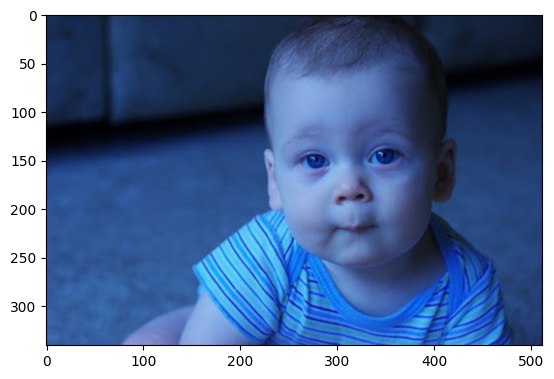

0.6392156862745098 0.8509803921568627 1.0


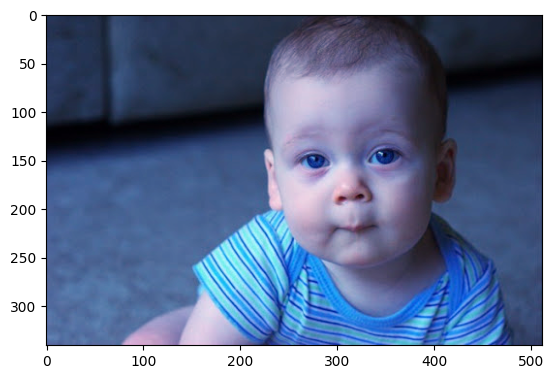

(<Figure size 640x480 with 1 Axes>,
 None)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io

img = io.imread("baby.jpg")
img = img[:,:,0:3]/255.0 # lucram in [0,1]
plt.figure(), plt.imshow(img), plt.show()

# gasim Rmax, Gmax, Bmax
rmax = np.max(img[:,:,0])
gmax = np.max(img[:,:,1])
bmax = np.max(img[:,:,2])

print(rmax, gmax, bmax)

img[:,:,0] = img[:,:,0] / (rmax) # could be / 0
img[:,:,1] = img[:,:,1] / (gmax)
img[:,:,2] = img[:,:,2] / (bmax)

plt.figure(), plt.imshow(img), plt.show()

O a doua varianta presupune identificarea celui mai stralucitor pixel al scenei, ceea ce presupune o sortare a planului de luminanta. Pixelul avand luminanta maxima, $Y_{max}$ va fi caracterizat de tripletul RGB: $R_{max},G_{max},B_{max}$. Si in acest caz, tripletul coeficientilor de corectie este dat de aceleasi formule ca cele prezentate din ecuatia de mai sus.

### Exercitiul 2: Implementati a doua varianta a metodei "cel mai stralucitor obiect este alb". Identificati cazurile in care functioneaza corect, respectiv incorect.
Veti avea nevoie sa identificati locatia exacta a celui mai stralucitor pixel. Pentru a obtine linia si coloana maximului, puteti utiliza sintaxa:
```python
ind = np.unravel_index(np.argmax(A,axis=None),A.shape)
```
, unde ```ind[0]``` reprezinta linia si ```ind[1]``` reprezinta coloana de interes.

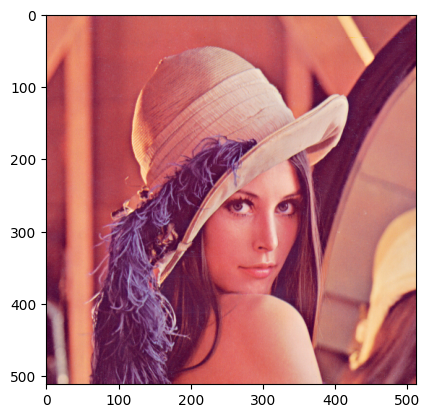

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.012096774193548387..1.0514018691588785].


0.984313725490196 0.9725490196078431 0.8392156862745098


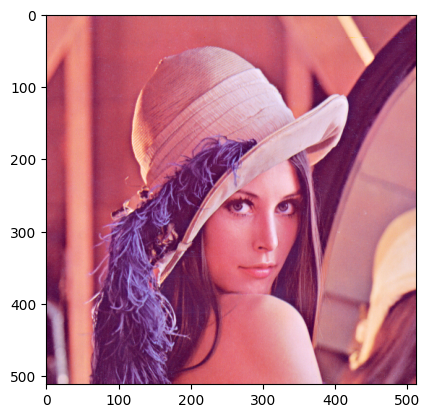

(<Figure size 640x480 with 1 Axes>,
 None)

In [ ]:
A = io.imread("lena.png")
A = A[:,:,0:3]/255.0 # lucram in [0,1]
img = color.rgb2ycbcr(A)
Y = img[:,:,0]

plt.figure(), plt.imshow(A), plt.show()

ind = np.unravel_index(np.argmax(Y,axis=None),Y.shape)
Rmax = A[ind[0],ind[1],0]
Gmax = A[ind[0],ind[1],1]
Bmax = A[ind[0],ind[1],2]

print(Rmax, Gmax, Bmax)

A[:,:,0] = A[:,:,0] / (Rmax) # could be / 0
A[:,:,1] = A[:,:,1] / (Gmax)
A[:,:,2] = A[:,:,2] / (Bmax)

plt.figure(), plt.imshow(A), plt.show()

## 3. Metoda "lumea este gri"
O alta abordare este sa se presupune ca "lumea este gri". Mai precis, aceasta ipoteza inseamna ca media fiecarui plan de culoare este aceeasi, $R_m=G_m=B_m$. In acest caz, se considera ca imaginea originala este in medie gri si imaginea obtinuta isi datoreaza deviatia spectrala componentelor sursei de lumina. In conditiile in care scena este suficient de variata ca si crominanta si are suficient de multe detalii distince, aceasta ipoteza este adevarata.

Pentru aceasta metoda exista mai multe variante. In solutia aleasa pentru exemplificare, vom presupune ca prin mediere pe fiecare plan s-au obtinut valorile: $R_m,G_m,B_m$. Atunci valoarea medie a scenei (nivelul de gri echivalent) este:
$$I_m = \frac{R_m+G_m+B_m}{3}$$

Presupunerea de baza este ca de fapt ar trebui sa obtineam $I_m=R_m=G_m=B_m$. In acest caz vom considera componentele sursei de lumina ca fiind:
$$kR=\frac{R_m}{I_m};kG=\frac{G_m}{I_m};kB=\frac{B_m}{I_m}$$

### Exercitiul 3: Implementati algoritmul mentionat. Identificati cazurile pe care functioneaza corect, respectiv incorect.

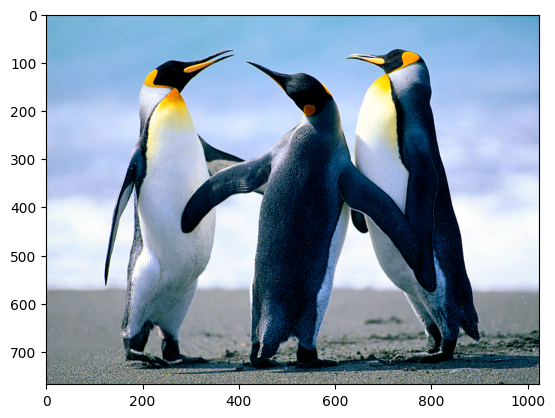

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.136025820145994].


0.5012609344681884 0.5805594201181449 0.6593309439864815


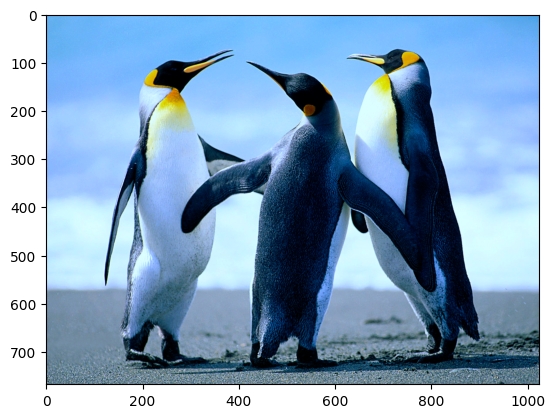

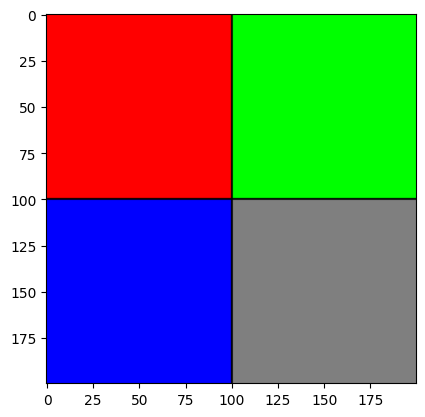

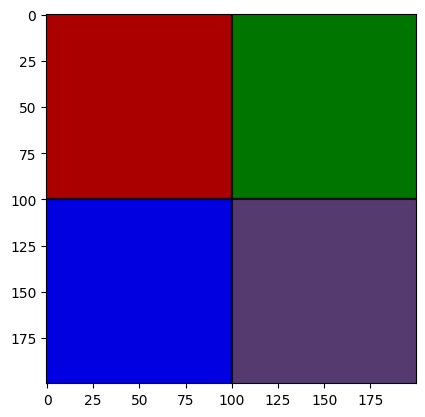

63.327125 43.16895 82.637775


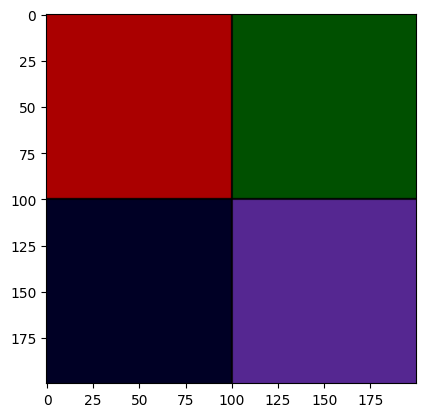

(<Figure size 640x480 with 1 Axes>,
 None)

In [49]:
img = io.imread("Penguins.jpg")
img = img[:,:,0:3]/255.0 # lucram in [0,1]
plt.figure(), plt.imshow(img), plt.show()

L,C,pl = np.shape(img)

Rm = np.mean(img[:,:,0])
Gm = np.mean(img[:,:,1])
Bm = np.mean(img[:,:,2])

print(Rm, Gm, Bm)

Im = (Rm+Gm+Bm)/3

kR = Rm/Im
kG = Gm/Im
kB = Bm/Im

img[:,:,0] = img[:,:,0] * kR
img[:,:,1] = img[:,:,1] * kG
img[:,:,2] = img[:,:,2] * kB

plt.figure(), plt.imshow(img), plt.show()

########################################

img2 = np.zeros((200,200,3), dtype=np.uint8)

L,C,_ = np.shape(img2)

img2[0:L//2,0:C//2]     = [255,0,0]
img2[L//2+1:L,0:C//2]   = [0,0,255]

img2[0:L//2,C//2+1:C]   = [0,255,0]
img2[L//2+1:L,C//2+1:C] = [255//2,255//2,255//2]

plt.figure(), plt.imshow(img2), plt.show()

img2[:,:,0] = img2[:,:,0]*0.67
img2[:,:,1] = img2[:,:,1]*0.46
img2[:,:,2] = img2[:,:,2]*0.88

plt.figure(), plt.imshow(img2), plt.show()

L,C,pl = np.shape(img2)

Rm = np.mean(img2[:,:,0])
Gm = np.mean(img2[:,:,1])
Bm = np.mean(img2[:,:,2])

print(Rm, Gm, Bm)

Im = (Rm+Gm+Bm)/3

kR = Rm/Im
kG = Gm/Im
kB = Bm/Im

img2[:,:,0] = img2[:,:,0] * kR
img2[:,:,1] = img2[:,:,1] * kG
img2[:,:,2] = img2[:,:,2] * kB

plt.figure(), plt.imshow(img2), plt.show()